# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval Quality Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [1]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

/tmp/ipykernel_7529/1608185913.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

Chat model: gpt-5.4-mini
Embedding model: text-embedding-3-small
LangSmith tracing: false


## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [3]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

Loaded 1 document(s).
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.

Preventive care is easier when owners track small changes over time. Useful observations include body weight, appetite, drinking, uri

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines'}


### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [4]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

Created 10 chunks.
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 0, 'chunk_id': 0}


### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [5]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

Built in-memory Qdrant collection: cat_health_agentic_rag


## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [6]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [7]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.673]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.666]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:
_When retrieval is a mandatory first step, the system always retrieves context before the LLM sees the query, even when it's completely unnecessary. But when it becomes a tool, the LLM decides if, when, and how many times to retrieve based on what it actually needs to answer the question._
_There are 5 dimensions to this change:_
* __Control flow__ _the LLM actively decides whether to invoke retrieval at all, instead of it just happening automatically._
* __When retrieval fires__ _there are cases where we don't need any external context. Agentic RAG can recognize that and skip retrieval entirely, rather than stuffing the prompt with irrelevant chunks._
* __Query construction__ _an agentic system can reason about what to search for. It can decompose a complex question into targeted sub-queries, or reformulate the query before passing it to the retrieval tool; instead of just throwing the raw user input at the vector DB. And crucially, it can rewrite the next search based on what came back from the last one, not just the original question. The tool's name, docstring, and input/output format is what actually guides these decisions reliably; when the docstring lists specific topics or constraints, the agent knows when retrieval is worth calling and what to ask for._
* __Multi-step chaining__ _the agent's answer to one retrieval can directly inform the next query. It's not just retrying on failure, it's using what it learned to go deeper. Each retrieval step builds on the previous one, which is something a fixed pipeline simply can't do._
* __Error recovery__ _when retrieval returns bad or irrelevant chunks, an agentic system can recognize that and try again with a different query (because we have a loop), or decide it already has enough context to stop. A pipeline has no way to do either._

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [8]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")



agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:

_Middleware lets us hook into the agent loop at the model boundary without touching the loop itself. We can observe what the model is about to receive at each step, react to what it just returned, limit how many times it gets called, swap out the prompt or tools for a specific call, or add things like summarization and human-in-the-loop checks. The loop stays exactly as it is and we're just adding checkpoints around it that we can plug in and swap out independently. Multiple middleware can be stacked in a list and each one runs independently in order, which means we can plug them in, combine them, or swap them out without any of them knowing about the others._

_The model-call limit is useful because without it, a vague query or a bad retrieval result can send the agent into a loop where it keeps retrieving and re-calling the model without ever converging on an answer. The limit puts a hard ceiling on that; After N calls, stop and return whatever you have. During development it saves you from runaway loops eating tokens. In production it matters even more, because we need predictable cost and latency per request and we can't let a single confused agent run indefinitely._

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

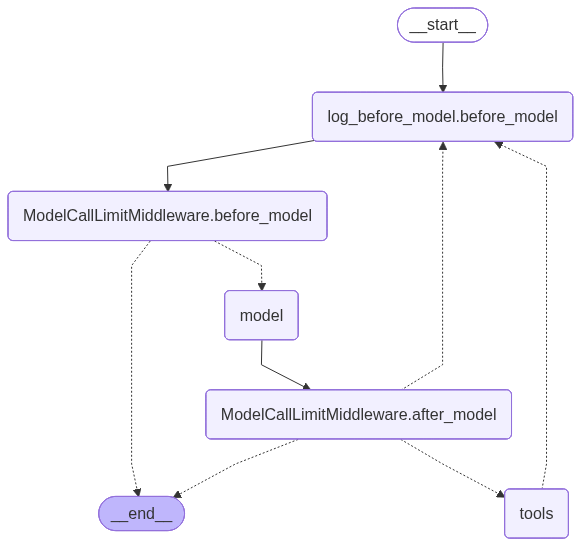

In [9]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [10]:
def print_agent_stream(question: str):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [14]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_RbWYOVRcQZA2KWcaxsA9TTY4)
 Call ID: call_RbWYOVRcQZA2KWcaxsA9TTY4
  Args:
    query: urinary signs urgent veterinary care cat warning signs emergency inability to urinate blood in urine straining frequent trips litter box

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.771]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarr

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [12]:
print_agent_stream("What preventive care should an adult cat get each year?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_YkIhkhVH7Md5G0m2RCZQhYVW)
 Call ID: call_YkIhkhVH7Md5G0m2RCZQhYVW
  Args:
    query: adult cat annual preventive care yearly exam vaccines parasite prevention dental care monitoring hydration weight guidance

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.747]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [13]:
print_agent_stream("Who won the 2022 FIFA World Cup?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that question here.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}


#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

* __Example 1__: _Yes, it called the retrieval tool. The question was directly about cat urinary symptoms, which is explicitly listed in the system prompt as a topic that should trigger retrieval. The agent recognized it needed external context to answer accurately and called the tool before generating a response._
* __Example 2__: _Yes, it called the retrieval tool. Same reason, preventive care is another topic the system prompt scopes to the corpus. Worth noticing here that the agent constructed a much more detailed search query than the user's original question, breaking it down into specific sub-topics like vaccines, parasite prevention, dental care, and hydration. That's the query construction dimension from Question 1 in action._
* __Example 3__: _No, it did not call the retrieval tool. The question had nothing to do with cat health, so the agent correctly skipped retrieval entirely and just responded directly from the system prompt instruction that says to stay scoped to the cat health corpus. This is also from Question 1, the agent doesn't retrieve when it doesn't need to, and in this case it didn't need the corpus at all to handle an out-of-scope question._

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

In [17]:
# Activity #1 workspace
retrieval_budget = ToolCallLimitMiddleware(
    tool_name=retriever_tool.name, 
    run_limit=1, 
    exit_behavior='continue'
)

budgeted_agent_middleware = agent_middleware + [retrieval_budget]


budgeted_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=budgeted_agent_middleware,
)


def print_stream_by_agent(question: str, agent):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)


In [18]:
print_stream_by_agent(
    question="What urinary signs suggest my cat needs urgent veterinary care and what preventive care should an adult cat get each year?",
    agent=budgeted_agent
)

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_T1X5dEma2TWVkSJ50qNwUAoC)
 Call ID: call_T1X5dEma2TWVkSJ50qNwUAoC
  Args:
    query: urinary signs that suggest a cat needs urgent veterinary care
  retrieve_cat_health_guidelines (call_Qpi9x95mcm3XhucucdFKfJiP)
 Call ID: call_Qpi9x95mcm3XhucucdFKfJiP
  Args:
    query: preventive care adult cat each year annual care vaccines parasite prevention dental exam

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from node: ModelCallLimitMiddleware.after_mod

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?
- Which call did the middleware allow or block?
- What quality or safety trade-off does this budget introduce?

##### Answer:

* __Which retrieval calls did the agent attempt?__
_The agent planned two retrieval calls in the same turn: one for urinary emergency signs and one for annual preventive care. It recognized the question had two distinct sub-topics and tried to search for them separately, which is the query construction behavior from Question 1._
* __Which call did the middleware allow or block?__
_The middleware allowed the first call and blocked the second; but the mechanism is worth being precise about. It didn't wait for the first call to finish and then block the next one. It intercepted at the model boundary, saw that two calls were planned, and injected a fake "Tool call limit exceeded" result for the second one before anything actually ran. Then the tools node executed only the first retrieval. The net effect is the same, one call goes through, one doesn't, but the budget check happens before the tools run, not between them._
* __What quality or safety trade-off does this budget introduce?__
_The trade-off is predictability vs completeness. The budget gives us a hard guarantee on retrieval cost per run, one vector search, no matter what the question asks. In production that's valuable for controlling latency and cost. But the quality cost is real. A multi-part question like this one genuinely needs two searches to answer well, and the budget forces the agent to either work with whatever the first query returned or admit it doesn't have enough information. In this case the agent handled it gracefully and was honest about the gap. But that's not guaranteed we're structurally trading answer quality for operational control, and that's a decision that should be made deliberately based on how the application is actually used._

## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [32]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")

Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

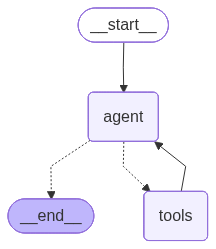

In [20]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [21]:
def print_langgraph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [22]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_sH6ZvWthm3WPlq14qN9YztKx)
 Call ID: call_sH6ZvWthm3WPlq14qN9YztKx
  Args:
    query: urinary signs that suggest a cat needs urgent veterinary care, urinary emergency warning signs, difficulty urinating, blood in urine, inappropriate urination, frequent trips to litter box, straining, no urine, vocalizing

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.793]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly 

In [23]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that here.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:

**What parts did `create_agent` hide that the explicit LangGraph version made visible?**

*Four specific things became visible when writing it out manually.*
- `llm.bind_tools(...)` *this is what actually gives the model knowledge that tools exist and lets it decide to call them. create_agent did this internally, you never saw it.*
- `StateGraph(MessagesState)` with named nodes *in create_agent there was no mention of an agent node or a tools node. They existed, but they were hidden inside the abstraction. Here you define them explicitly and wire them together yourself.*
- `add_conditional_edges("agent", tools_condition)` *this is the decision point that makes the loop work. After every model call, tools_condition checks: did the model ask to call a tool? If yes, go to the tools node. If no, go to END. create_agent was making this decision the whole time, just silently.*
- `add_edge("tools", "agent")` *this is what creates the loop. After the tools node runs, it sends control back to the agent node. That's the cycle. It was never visible before.*

**When would you choose middleware vs changing the graph?**

*Middleware is the right choice when you want to observe or constrain what happens around the model call without changing the flow, logging, call limits, summarization, guardrails. The loop shape stays exactly the same. You change the graph when you need to change the flow itself, adding nodes, changing routing, branching based on what came back from a tool. A good way to think about it: could you implement deterministic scope routing with middleware alone? No, because middleware doesn't control edges. That's a graph-level decision, and middleware simply can't reach it.*

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [27]:
# Activity #2 workspace
# Define your out_of_scope node, routing function, and routed graph here.
from langchain_core.messages import AIMessage


def out_of_scope(state: MessagesState):
    """Return a fixed message for clearly out-of-scope questions."""
    return {
        "messages": [AIMessage(content="This assistant is scoped to cat health guidelines only. I can't help with that question here.")]
    }

CAT_HEALTH_KEYWORDS = [
    "cat", "cats", "kitten", "feline",
    "vet", "veterinarian", "veterinary",
    "symptom", "symptoms", "sick", "illness", "disease",
    "vaccine", "vaccination", "parasite", "flea", "tick", "worm",
    "dental", "teeth", "tooth",
    "urinary", "urine", "litter", "litter box",
    "food", "nutrition", "diet", "water", "hydration",
    "senior", "aging", "behavior", "stress", "grooming",
    "weight", "appetite", "vomiting", "diarrhea", "bleeding",
    "pain", "limping", "coughing", "sneezing", "hiding",
]

def route_question(state: MessagesState):
    """Send cat-health questions to the agent, clearly unrelated ones to out_of_scope."""
    last_message = state["messages"][-1].content.lower()
    if any(keyword in last_message for keyword in CAT_HEALTH_KEYWORDS):
        return "agent"
    return "out_of_scope"


routed_builder = StateGraph(MessagesState)

routed_builder.add_node("agent", call_model)
routed_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))
routed_builder.add_node("out_of_scope", out_of_scope)

routed_builder.add_conditional_edges(START, route_question)
routed_builder.add_conditional_edges("agent", tools_condition)
routed_builder.add_edge("tools", "agent")
routed_builder.add_edge("out_of_scope", END)

routed_agent = routed_builder.compile()
print("Compiled the routed LangGraph agent.")


# --- Test 1: Cat health question ---
print("\n=== Test 1: Cat health question ===")
print_stream_by_agent("What urinary signs suggest my cat needs urgent veterinary care?", routed_agent)

# --- Test 2: Unrelated question ---
print("\n=== Test 2: Unrelated question ===")
print_stream_by_agent("Who won the 2022 FIFA World Cup?", routed_agent)

# --- Test 3: Ambiguous question ---
print("\n=== Test 3: Ambiguous question ===")
print_stream_by_agent("What should I feed to stay healthy?", routed_agent)

Compiled the routed LangGraph agent.

=== Test 1: Cat health question ===

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_KGebzdJrCHRvs7FOPpOjumzj)
 Call ID: call_KGebzdJrCHRvs7FOPpOjumzj
  Args:
    query: urinary signs that suggest urgent veterinary care in cats

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.665]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased ur

### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:

**Which questions bypassed the model-tools loop?** 
*Tests 2 and 3 both bypassed the loop entirely. The FIFA question had no cat health keywords so it went straight to `out_of_scope`. The ambiguous question ("What should I feed to stay healthy?") did too, "feed" isn't in the keyword list, and neither is any other cat-related term, so the router sent it to `out_of_scope` without ever touching the model.*

**What happened with the ambiguous question?** *It got blocked even though it could reasonably be a cat nutrition question. The keyword router only sees the words in the message, not the intent behind them. Someone asking about feeding their cat without saying "cat" gets the same response as someone asking about football. That's the brittleness; the route is fast and cheap but it has no understanding, just pattern matching.*

**What are the cost, latency, and quality trade-offs?** *On the cost and latency side this is a clear win for unrelated questions. No LLM call, no retrieval, instant response. For a production app that gets a lot of off-topic traffic, that adds up. The quality trade-off is the problem. The model-based approach from the base agent was actually more reliable for edge cases. t could understand intent even when the phrasing was unusual. The keyword router can't. It will over-block ambiguous but valid questions like Test 3, and it could also under-block something like "my pet won't eat" which is clearly cat-health adjacent but has no keyword match. The deterministic route is predictable and cheap, but you're trading away the model's ability to handle anything that doesn't fit neatly into the keyword list.*

## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

In [56]:
from langchain_core.documents import Document
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

class AdvancedState(MessagesState):
    retry_count: int
    documents: list[Document]


def document_grader(state: AdvancedState) -> str:

    if state.get("retry_count", 0) >= 3:
        return "agent" 

    question = state["messages"][-1].content
    docs = state["documents"]
    
    chunks = "\n\n".join([doc.page_content for doc in docs])
    
    result = llm.invoke([
        ("system", (
            "You are a relevance grader. Given a question and retrieved document chunks, "
            "decide if the chunks contain information useful for answering the question. "
            "Reply with a single word: 'relevant' or 'not_relevant'."
        )),
        ("human", f"Question: {question}\n\nRetrieved chunks:\n{chunks}"),
    ])

    if "not_relevant" not in result.content.lower():
        return "agent"
    return "rewrite"


def rewrite_query(state: AdvancedState):
    question = state["messages"][-1].content
    
    result = llm.invoke([
        ("system", (
            "You are a query rewriter for a cat health retrieval system. "
            "The previous retrieval did not return relevant results. "
            "Rewrite the user's question into a more specific, targeted search query "
            "that is more likely to match content in the cat health guidelines. "
            "Return only the rewritten query, nothing else."
        )),
        ("human", question),
    ])
    
    return {
        "messages": [HumanMessage(content=result.content)],
        "retry_count": state.get("retry_count", 0) + 1,
    }



def call_model(state: AdvancedState):
    context = "\n\n".join([doc.page_content for doc in state["documents"]])
    response = llm.invoke(
        [
            SystemMessage(content=AGENT_SYSTEM_PROMPT + "\n\nRetrieved context:\n" + context)
        ] + state["messages"]
    )

    return {"messages": [response]}


def retriever(state: AdvancedState):
    query = state["messages"][-1].content
    result = vector_store.similarity_search_with_score(query, k=retrieval_k)
    return {
        "documents": [doc for doc, score in result]
    }


def out_of_scope(state: AdvancedState):
    return {
        "messages": [AIMessage(content="This assistant is scoped to cat health guidelines only. I can't help with that question here.")]
    }


def route_question(state: AdvancedState):
    last_message = state["messages"][-1].content.lower()
    if any(keyword in last_message for keyword in CAT_HEALTH_KEYWORDS):
        return "retriever"
    return "out_of_scope"


advanced_builder = StateGraph(AdvancedState)

advanced_builder.add_node("agent", call_model)
advanced_builder.add_node("retriever", retriever)
advanced_builder.add_node("rewrite", rewrite_query)
advanced_builder.add_node("out_of_scope", out_of_scope)

advanced_builder.add_conditional_edges(
    START, 
    route_question,
    {"retriever": "retriever", "out_of_scope": "out_of_scope"}
)

advanced_builder.add_conditional_edges(
    "retriever",
    document_grader,
    {"agent": "agent", "rewrite": "rewrite"}
)

advanced_builder.add_edge("rewrite", "retriever")           
advanced_builder.add_edge("agent", END)                     
advanced_builder.add_edge("out_of_scope", END)              

advanced_agent = advanced_builder.compile()
print("Compiled the advanced LangGraph agent.")

Compiled the advanced LangGraph agent.


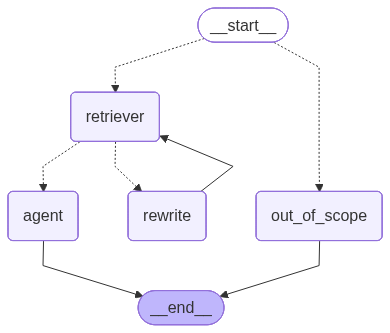

In [54]:
try:
    display(Image(advanced_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(advanced_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")


In [ ]:
# check

# --- Test 1: Cat health question ---
print("\n=== Test 1: Cat health question ===")
print_stream_by_agent("What urinary signs suggest my cat needs urgent veterinary care?", advanced_agent)

# --- Test 2: Unrelated question ---
print("\n=== Test 2: Unrelated question ===")
print_stream_by_agent("Who won the 2022 FIFA World Cup?", advanced_agent)

# --- Test 3: Ambiguous question ---
print("\n=== Test 3: Ambiguous question ===")
print_stream_by_agent("What should I feed to stay healthy?", advanced_agent)


=== Test 1: Cat health question ===

--- Update from node: retriever ---
{'documents': [Document(metadata={'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 3071, 'chunk_id': 5, '_id': '2c1daf123ca64e82b9d03f4079727dfe', '_collection_name': 'cat_health_agentic_rag'}, page_content='## Symptoms That Need Veterinary Attention\n\nVeterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.\n\nNon-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.'), Document(

### Advanced build notes:

- **What you changed**

*Four things: a dedicated `retriever` node that calls the vector store directly instead of relying on a model tool call, a `document_grader` node that routes to either `agent` or `rewrite` based on chunk relevance, a `rewrite_query` node that rewrites the question and loops back to retrieval when grading fails, and the deterministic scope router from Activity 2 as the entry point.*

- **Why you changed it**

*The base agent left retrieval decisions to the model, which means it could skip retrieval, retrieve too late, or use a poorly formed query. This version makes retrieval mandatory and adds a feedback loop - retrieve, grade, rewrite if needed, retry - with a hard ceiling of 3 attempts handled directly in the routing logic instead of middleware.*

- **How the agent's retrieval decisions or answer quality changed**

*The agent no longer decides whether to retrieve, the graph does. For a scoped domain this removes a whole class of variability. The grader gives the agent multiple chances to get relevant chunks before generating an answer, and injecting documents directly into the system prompt gives the model a cleaner view of its context compared to chunks buried in tool message history.*

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.